In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML

# Import data

In [2]:
df = spoti.load_all_tracks(base_path=data_path.DATA_PATH, users=users_list.USERS, load_spotify_tracks=True)
df

,album,artists,available_markets,disc_number,duration_ms,episode,explicit,external_ids,external_urls,href,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,affinity,release_year,normalized_genres
0,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,251488,False,False,{'isrc': 'GBF088590110'},{'spotify': 'https://open.spotify.com/track/4R...,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,...,audio_features,spotify:track:4RvWPyQ5RL0ao9LPZeSouE,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,https://api.spotify.com/v1/audio-analysis/4RvW...,251489,4,NaN,NaN,NaN,NaN
1,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,256146,False,False,{'isrc': 'GBF088590112'},{'spotify': 'https://open.spotify.com/track/74...,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,...,audio_features,spotify:track:748yv6bb3l3CcKS45a6SZ8,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,https://api.spotify.com/v1/audio-analysis/748y...,256147,4,NaN,NaN,NaN,NaN
2,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,209106,False,False,{'isrc': 'GBUM71103440'},{'spotify': 'https://open.spotify.com/track/7n...,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,...,audio_features,spotify:track:7nhWtCc3v6Vem80gYPlppQ,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,https://api.spotify.com/v1/audio-analysis/7nhW...,209107,4,NaN,NaN,NaN,NaN
3,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,170786,False,False,{'isrc': 'GBUM71029609'},{'spotify': 'https://open.spotify.com/track/4v...,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,...,audio_features,spotify:track:4vhVDkSx9RSb2k6mWFMYNI,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,https://api.spotify.com/v1/audio-analysis/4vhV...,170787,4,NaN,NaN,NaN,NaN
4,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,264253,False,False,{'isrc': 'GBUM71029621'},{'spotify': 'https://open.spotify.com/track/5R...,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,...,audio_features,spotify:track:5RYLa5P4qweEAKq5U1gdcK,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,https://api.spotify.com/v1/audio-analysis/5RYL...,264253,4,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20317,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,...,audio_features,spotify:track:3z7dWKRsjDNM24ohLKZBnA,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,https://api.spotify.com/v1/audio-analysis/3z7d...,251880,4,NaN,NaN,1967.0,"[rock, rock, rock, rock, rock, rock, rock]"
20318,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,...,audio_features,spotify:track:1VofMhhL98pewltVGBSmCW,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,https://api.spotify.com/v1/audio-analysis/1Vof...,193853,3,NaN,NaN,2017.0,"[rock, rock, rock, rock, rock]"
20319,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,False,{'isrc': 'GBLTP170

# Distribution

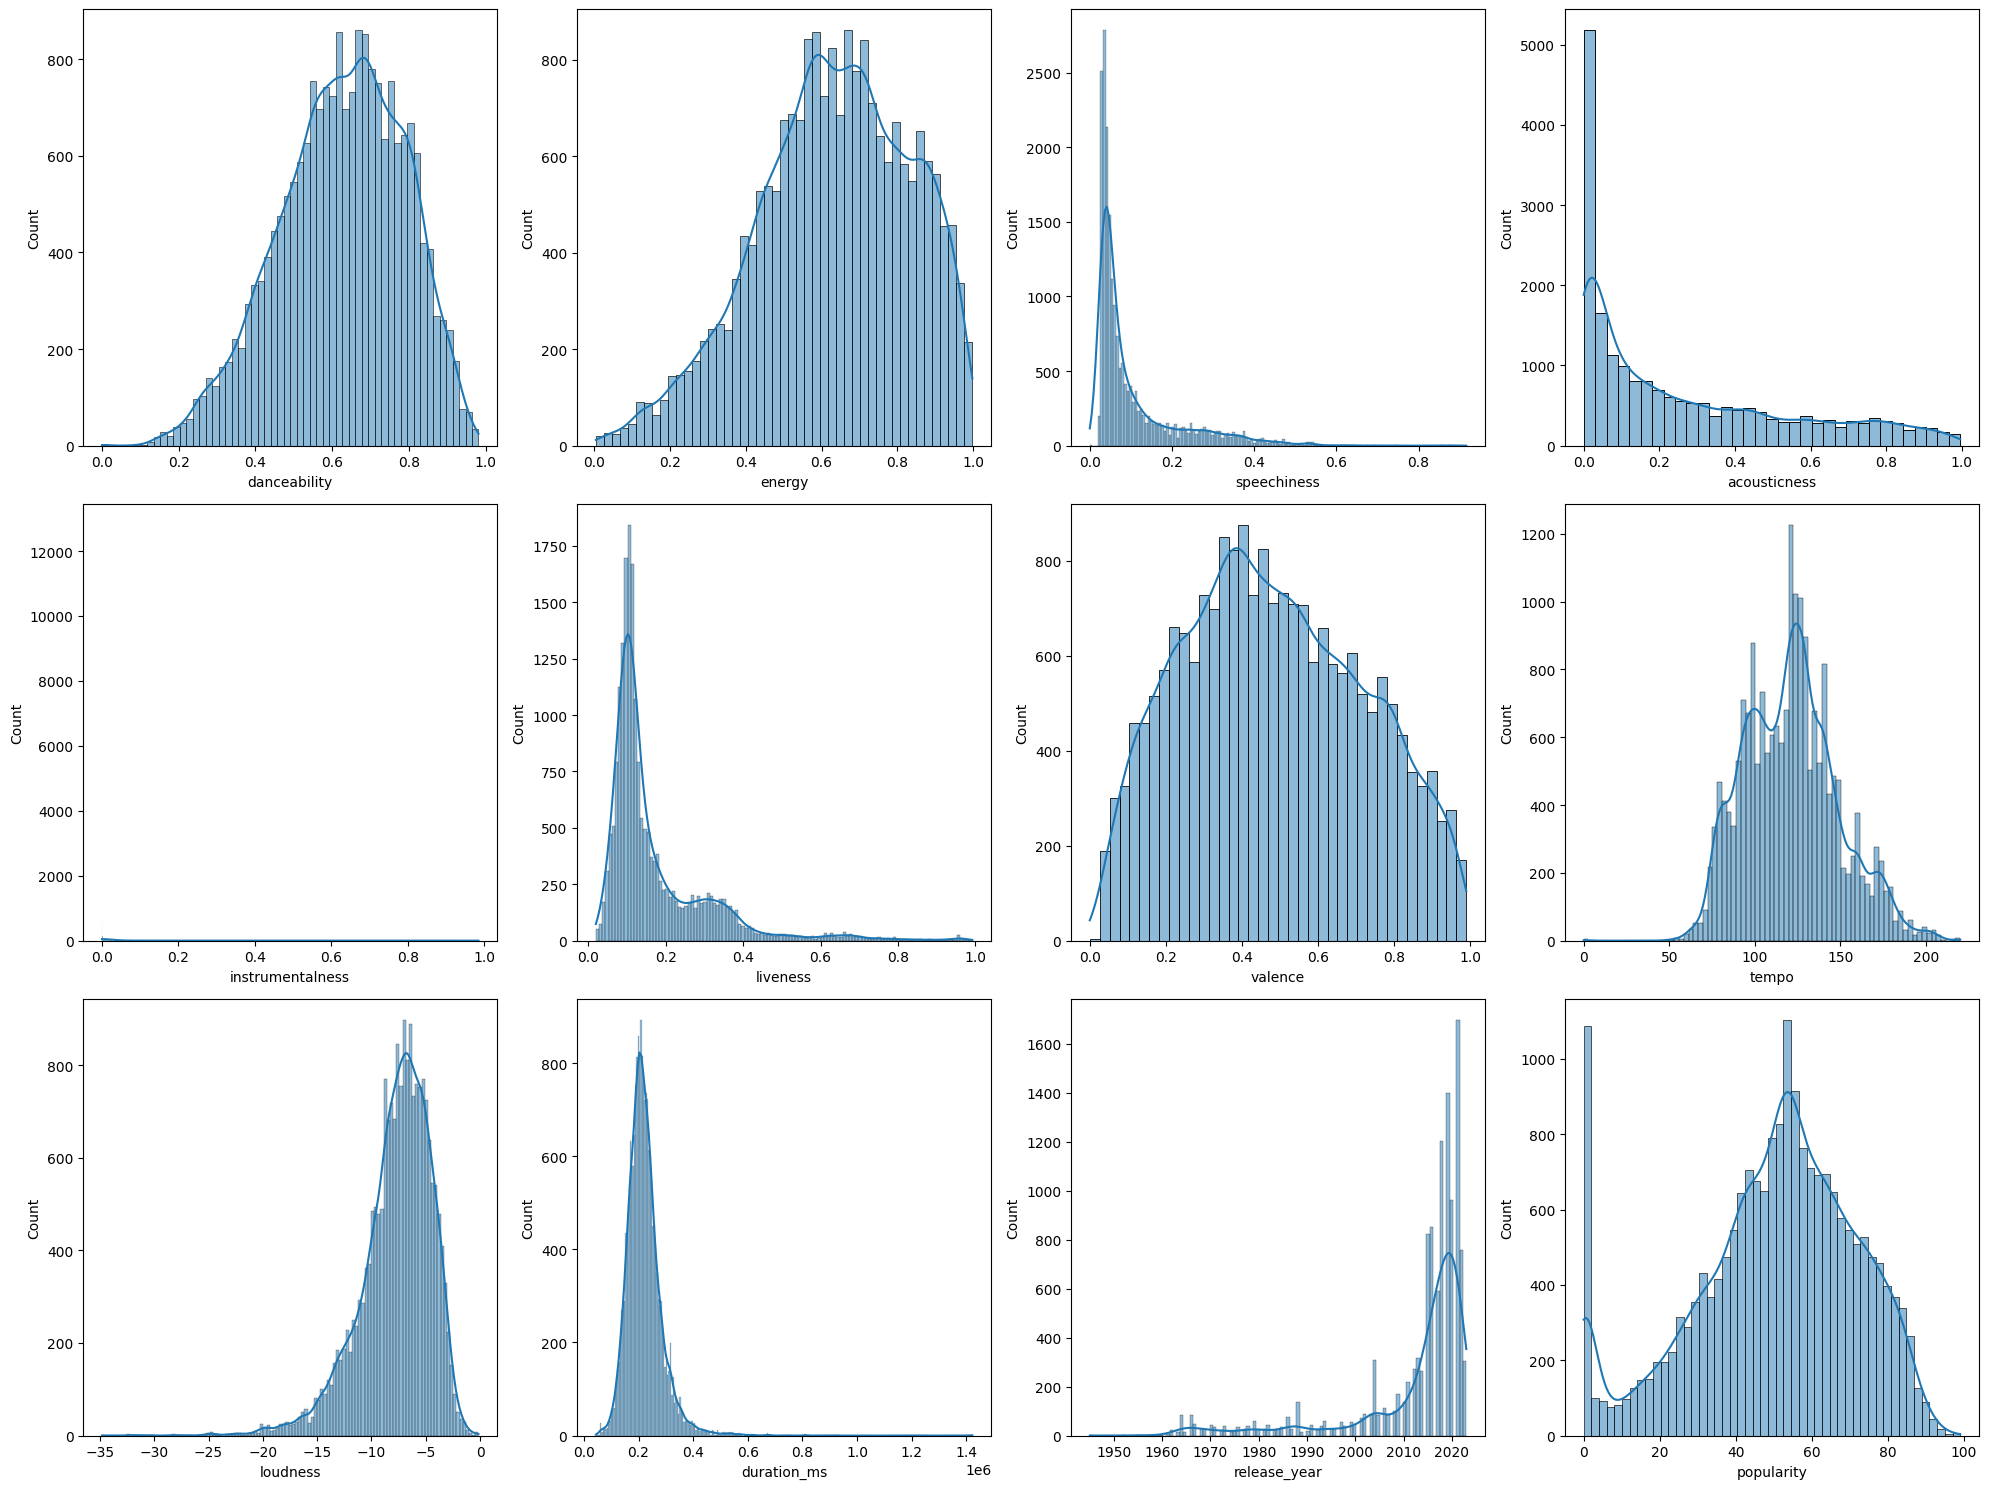

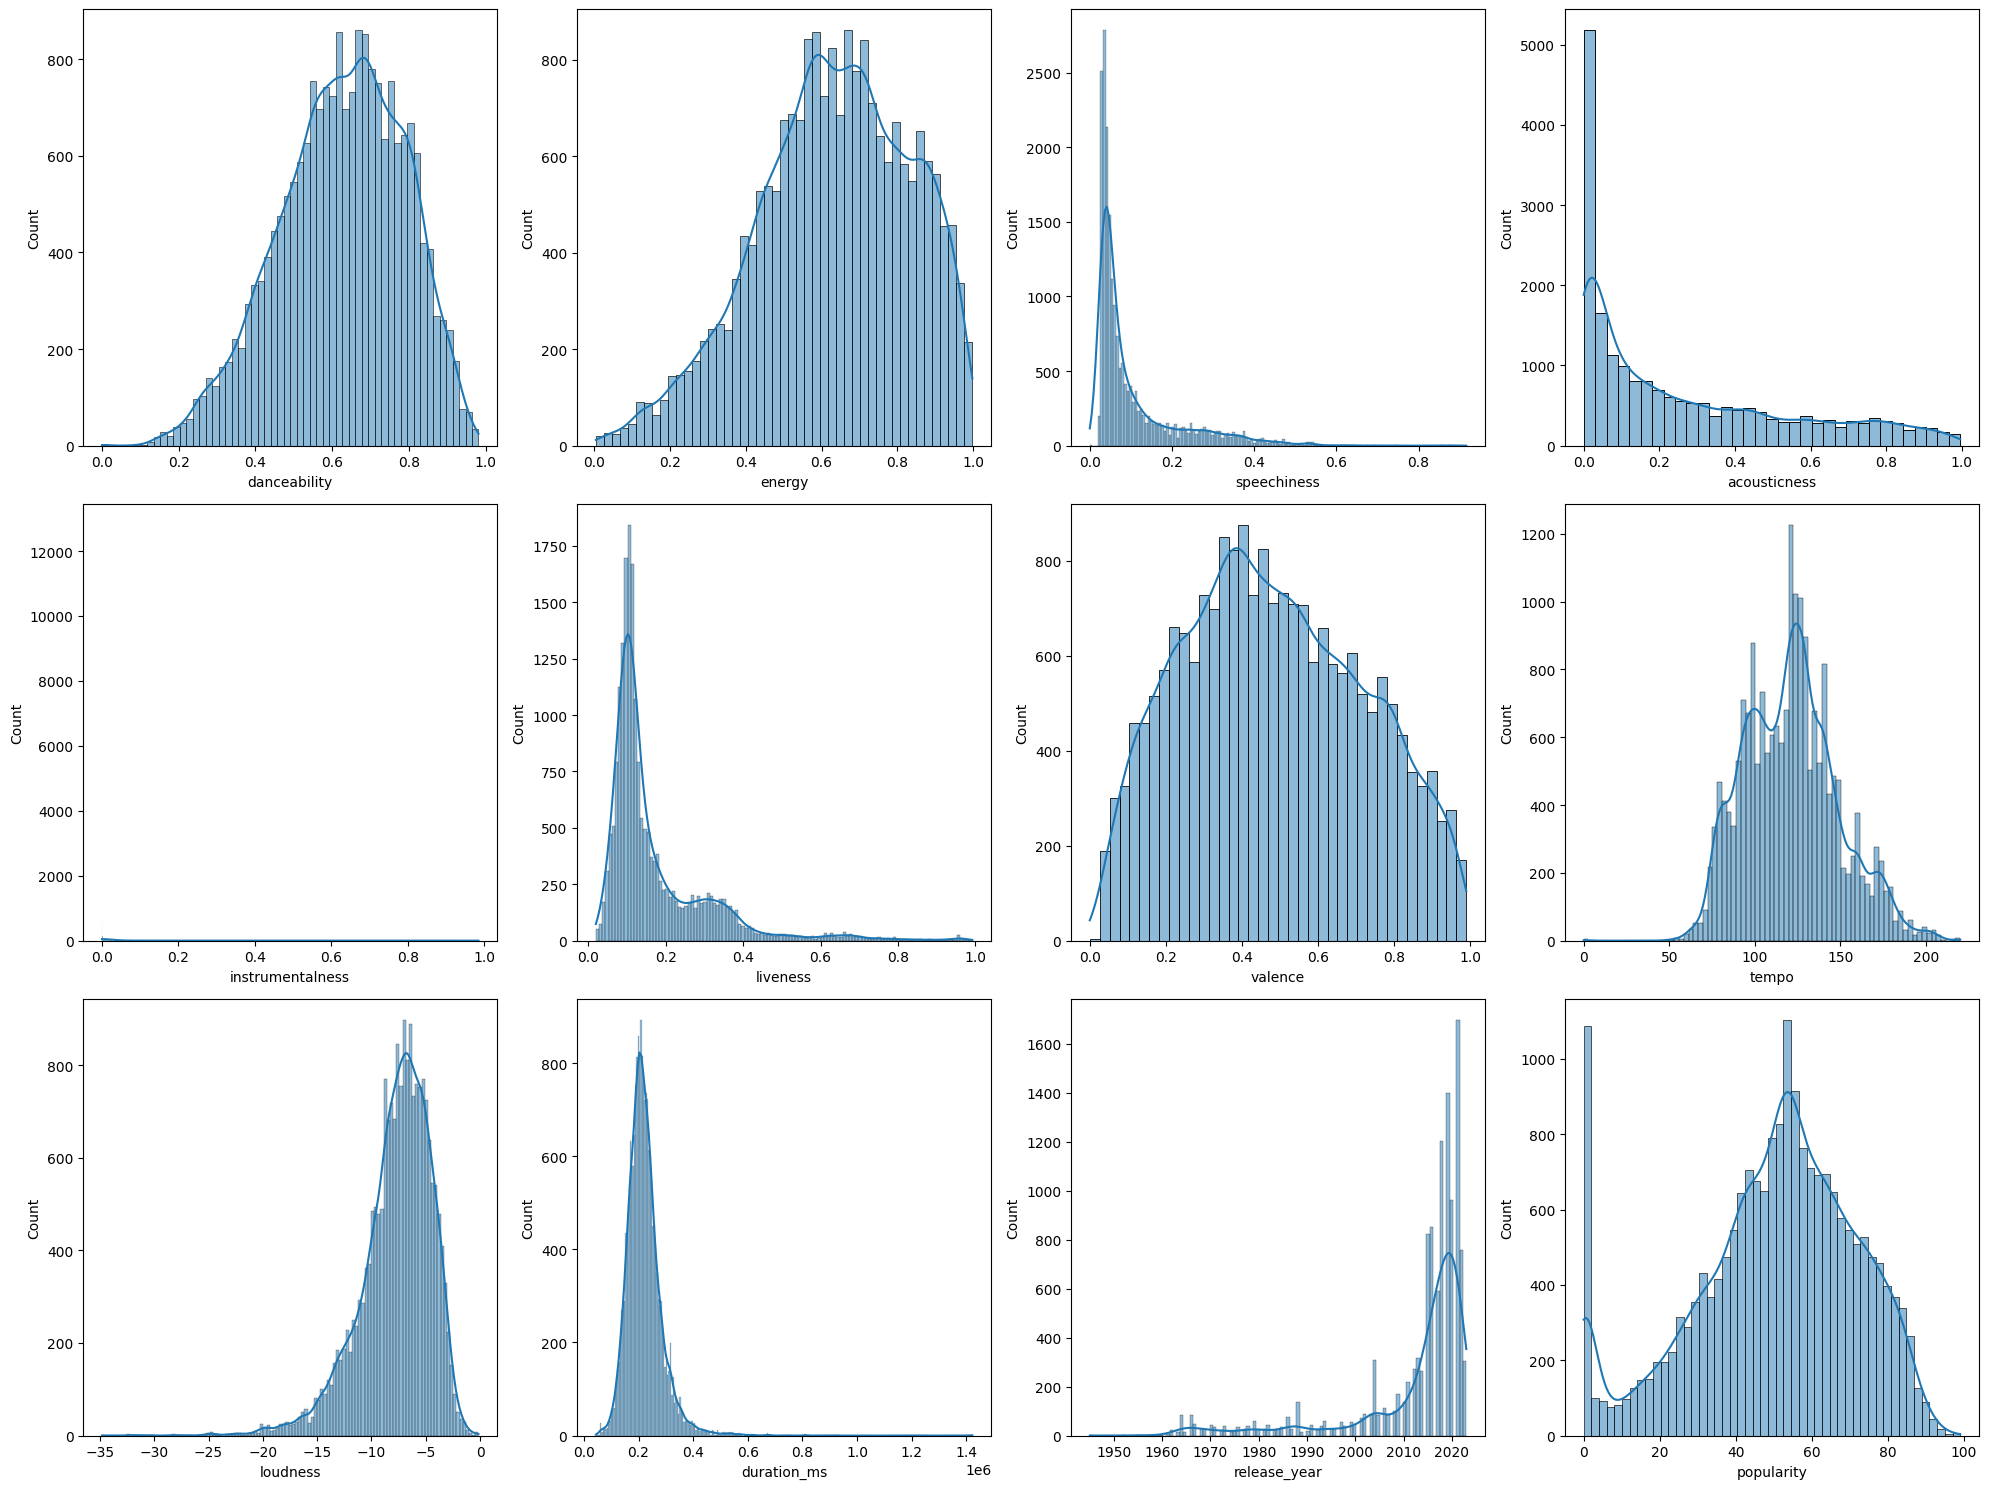

In [3]:
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=4, rows=3)

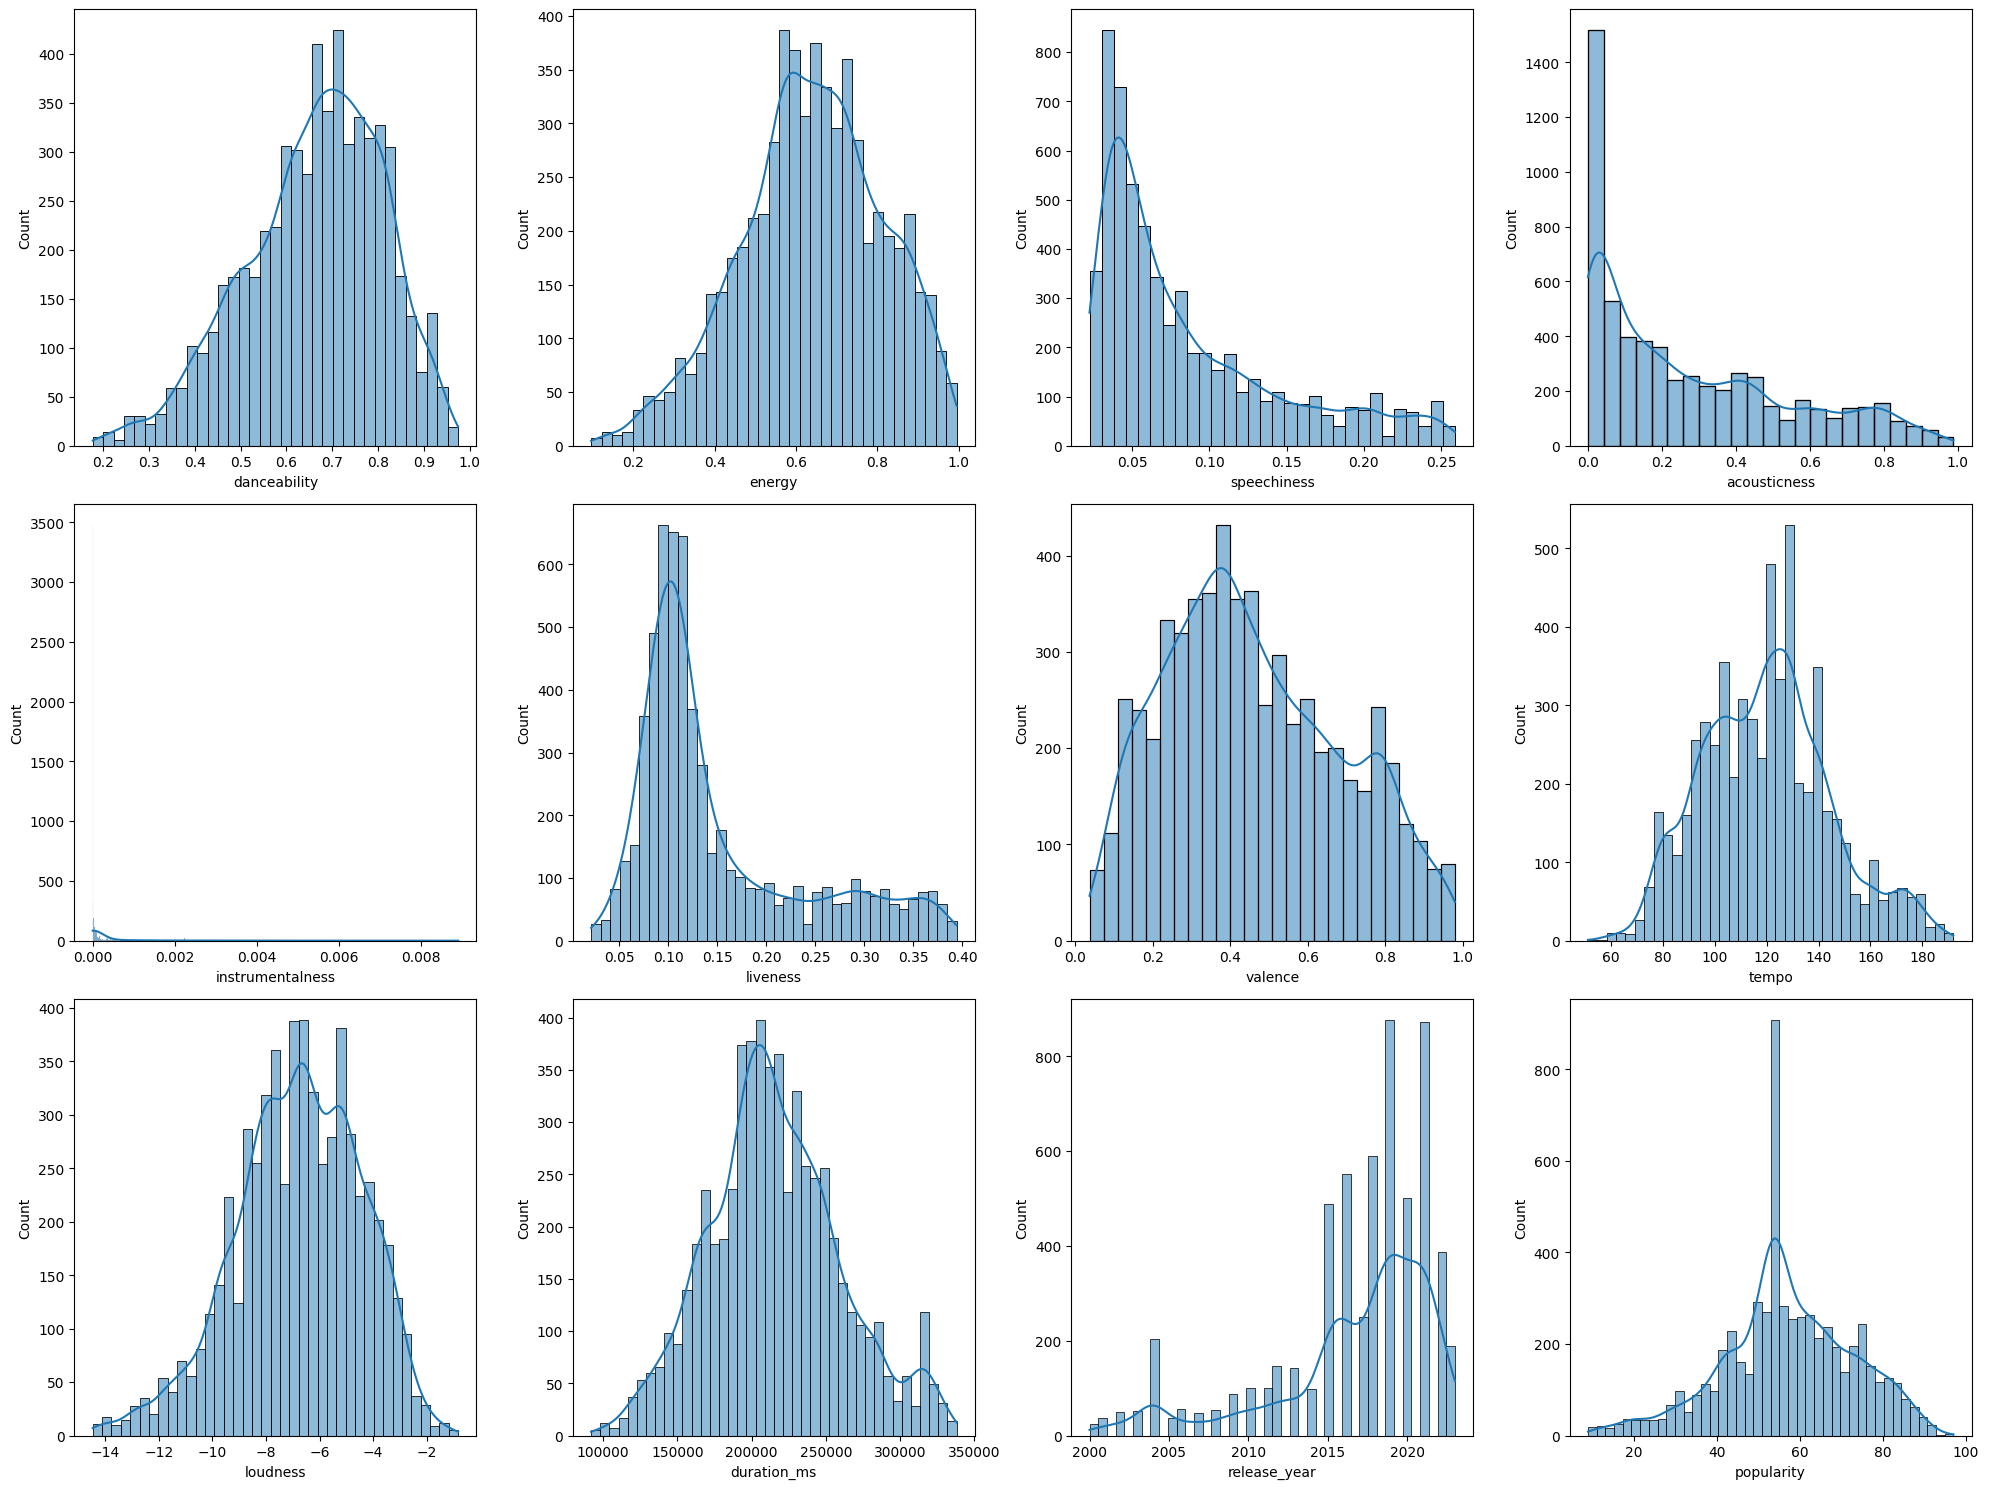

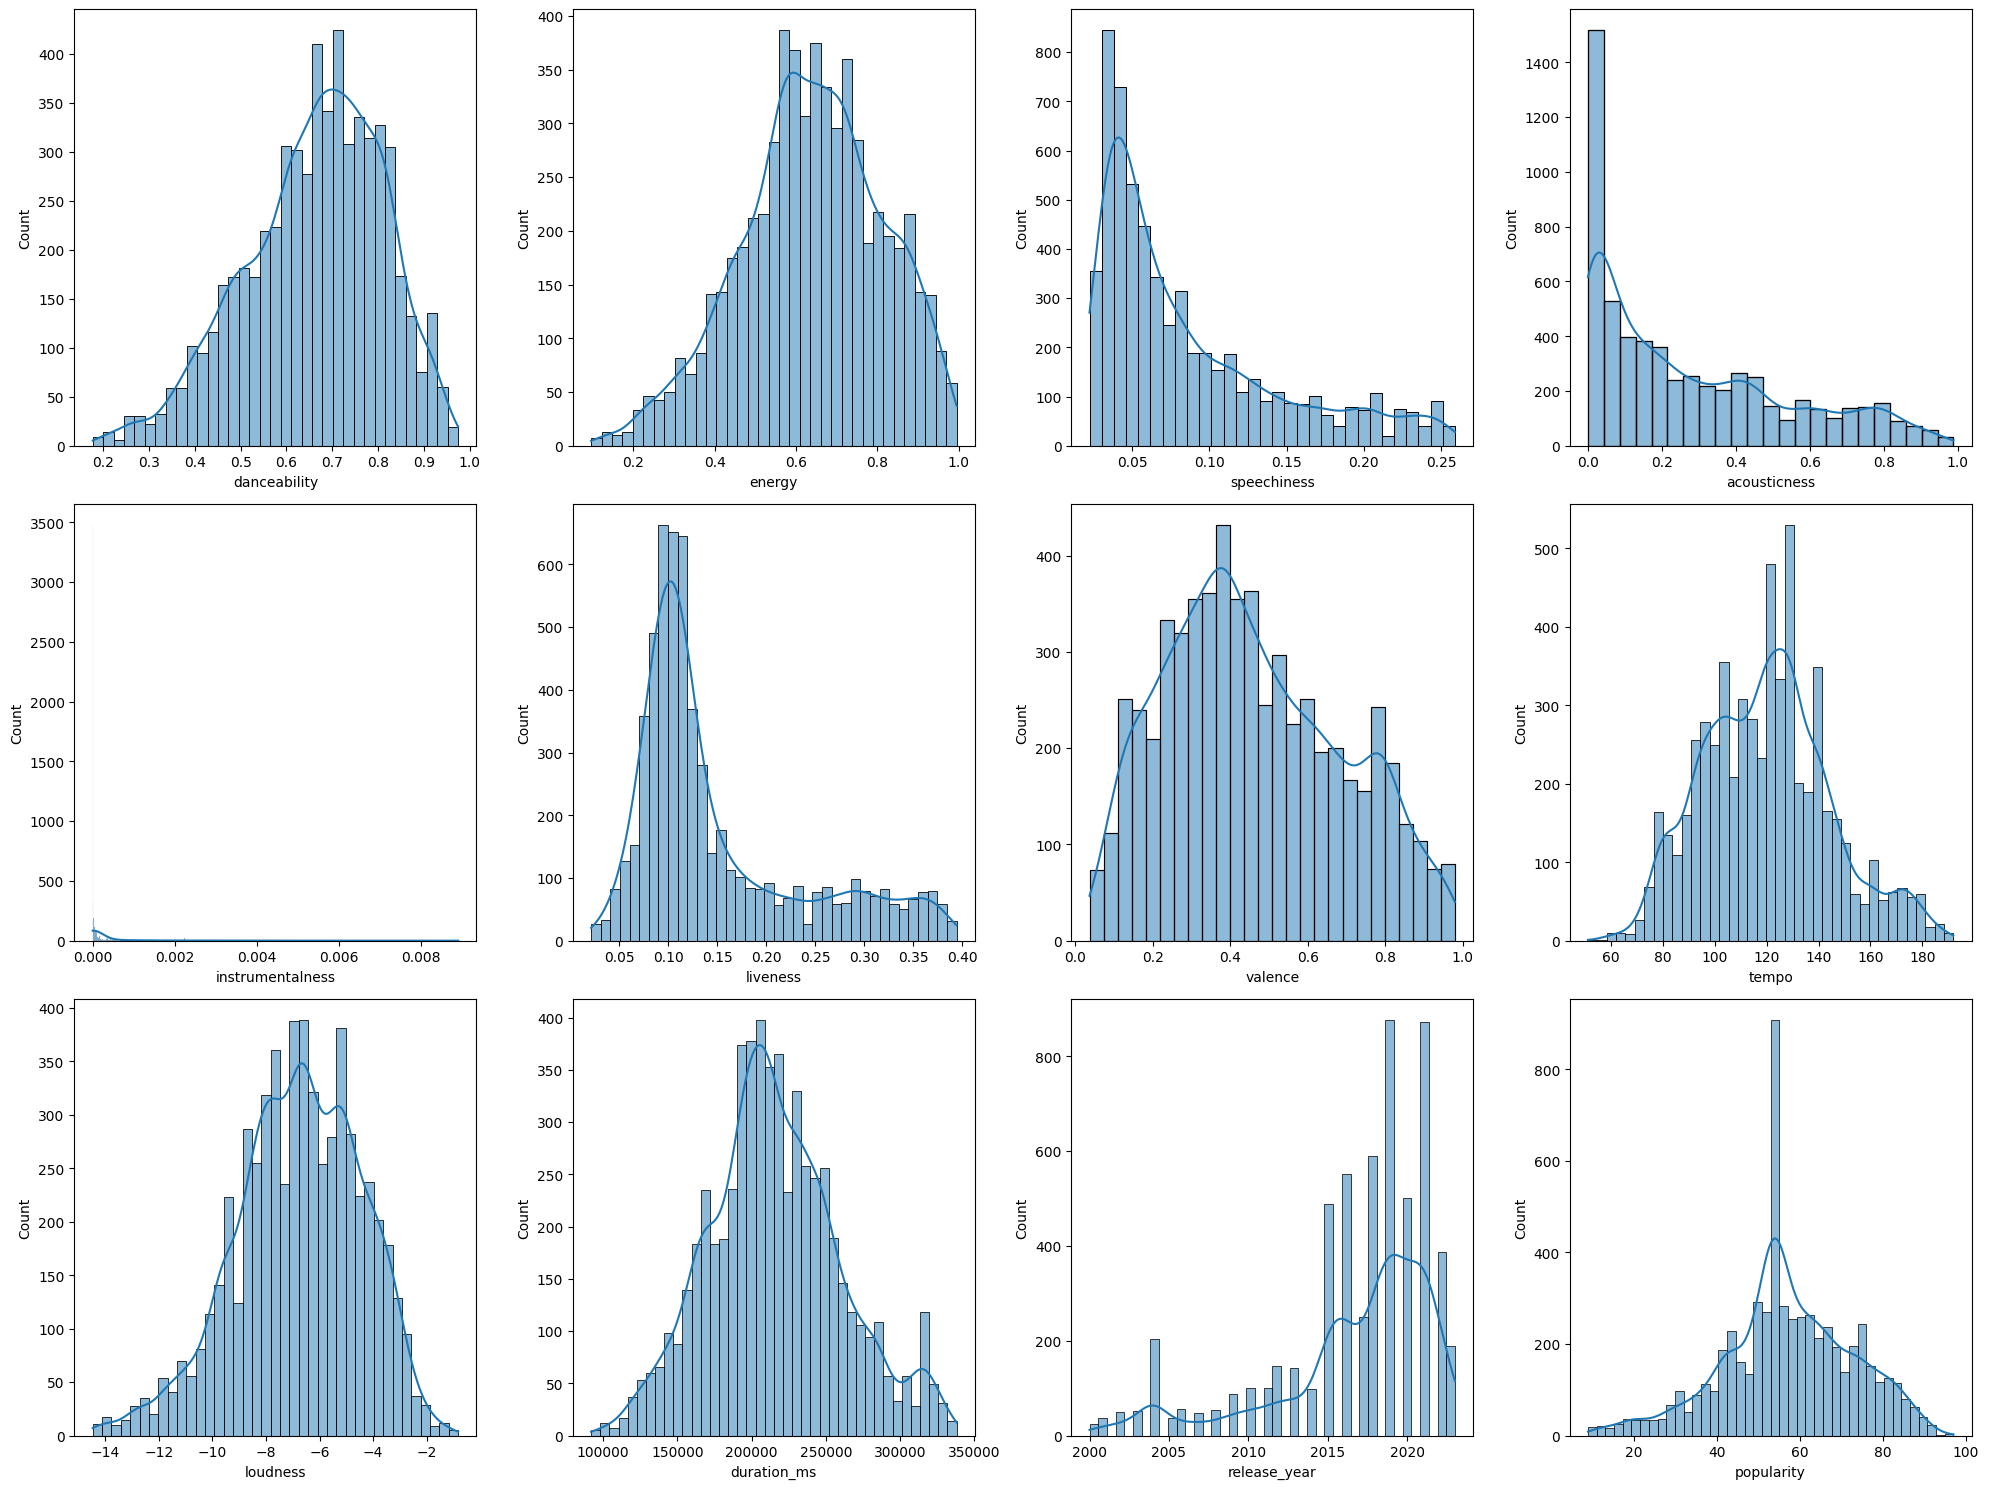

In [4]:
# Remove outliers based on IQR
df = preprocessing.remove_outliers_iqr(df, spoti.NUMERICAL_FEATURES, quantile=0.25, threshold=1.5)
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=4, rows=3)

In [5]:
plotting.plot_genres(df["genres"])

In [6]:
plotting.plot_genres(df["normalized_genres"])

# KNN

In [7]:
spoti.TRACKS_TYPES

['top_track', 'liked_track', 'playlist']

In [13]:
# From a user's perspective, we want to recommend songs that are similar to the songs that the user has listened to.
# We can use the cosine similarity to find the most similar songs to a given song.
df_knn = df.copy()

# df_knn = remove_outliers_iqr(df_knn, NUMERICAL_FEATURES, threshold=0.15)

# normalize numeric features
scaler = StandardScaler()
df_knn[spoti.NUMERICAL_FEATURES] = scaler.fit_transform(df_knn[spoti.NUMERICAL_FEATURES])

# Run PCA on the numeric features
n_components = len(spoti.NUMERICAL_FEATURES)
n_components = 8
pca = PCA(n_components=n_components)
latent_features = pca.fit_transform(df_knn[spoti.NUMERICAL_FEATURES])
df_knn, latent_columns = dimensionality_reduction.add_latent_features(df_knn, latent_features)
if n_components <= 3: plotting.plot_latent_space(df_knn, color=df_knn["username"], text=df_knn["username"], title="PCA").show()
latent_columns = spoti.NUMERICAL_FEATURES

# Choose a user
user = np.random.choice(users_list.USERS)
user = user.username
user = "dany"
print(f"User: {user}")

# Get songs that the user has listened to
track_types = ["top_track"]
df_knn_user = df_knn[df_knn["username"] == user]
df_knn_user = df_knn_user[df_knn_user["type"].isin(track_types)]
df_knn_user

# Sample N songs from the songs that the user has listened to, more chance of sampling central songs of the user
PRE_SELECT_N = 20
SELECT_N = 10
df_knn_user_sample = df_knn_user.sample(PRE_SELECT_N)
# sort by affinity with random weights
weights = np.random.rand(len(df_knn_user_sample)) * 2 + 1
df_knn_user_sample["affinity"] = df_knn_user_sample["affinity"] * weights
df_knn_user_sample = df_knn_user_sample.sort_values(by="affinity", ascending=False)
df_knn_user_sample = df_knn_user_sample.drop_duplicates(subset=["id"])
df_knn_user_sample = df_knn_user_sample.head(SELECT_N)
# shuffle the dataframe
display(df_knn_user_sample[spoti.PRETTY_PRINT_FEATURES + latent_columns])

# Get songs that the user has not listened to
df_knn_user_complement = df_knn[(~df_knn["id"].isin(df_knn_user["id"])) & (~df_knn["id"].isin(df_knn_user_sample["id"]))].drop_duplicates(subset=["id"])
df_knn_not_user = df_knn[(df_knn["username"] != user) & (~df_knn["id"].isin(df_knn_user_sample["id"]))].drop_duplicates(subset=["id"])

print(f"User songs selected: {len(df_knn_user)}")
print(f"User songs complement: {len(df_knn_user_complement)}")
print(f"Songs unknown to user: {len(df_knn_not_user)}")

# Get the songs that are most similar to the sampled songs
knn = NearestNeighbors(metric="minkowski", p=2, radius=1)

# From all the songs that the user has not listened to, we only want to consider the songs that are similar to the sampled songs
choosen_df = df_knn_user_complement
knn.fit(choosen_df[latent_columns])
distances, indices = knn.kneighbors(df_knn_user_sample[latent_columns], n_neighbors=1000, return_distance=True)
# Set the distances to the original dataframe
choosen_df = choosen_df.iloc[indices.flatten()].copy()
choosen_df["distance"] = distances.flatten()
choosen_df = choosen_df.sort_values(by="distance")
choosen_df = choosen_df.drop_duplicates(subset=["id"])

TOP_N = 20
choosen_df = choosen_df.head(TOP_N)
# shuffle the dataframe
choosen_df = choosen_df.sample(frac=1)

choosen_df[spoti.PRETTY_PRINT_FEATURES]

User: dany


,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
20122,dany,Feu! Chatterton,Monde Nouveau,0.843951,-0.251372,0.078571,-0.810339,-0.963842,-0.713330,2.408330,...,-0.963842,-0.713330,2.408330,0.214787,-1.524534,-0.525627,-1.094263,-0.028229,0.843951,-0.251372
20071,dany,Post Malone,Speedometer,1.234355,0.636567,0.272370,1.098444,-0.462457,-1.002922,1.777386,...,-0.462457,-1.002922,1.777386,2.175511,0.511683,-0.243781,-0.348549,-1.196926,1.234355,0.636567
20131,dany,Orelsan,Ensemble,0.843951,-0.314797,0.265688,-0.097420,-0.741004,-0.989797,-0.353973,...,-0.741004,-0.989797,-0.353973,-0.657159,-0.752635,-0.158635,-1.124553,1.504798,0.843951,-0.314797
20074,dany,Post Malone,Chemical,1.234355,1.017112,-1.171103,1.500898,-0.632961,-1.031097,-0.353973,...,-0.632961,-1.031097,-0.353973,-0.557969,-0.459845,2.041685,0.886914,-0.721354,1.234355,1.017112
20172,dany,Greta Van Fleet,Trip the Light Fantastic,0.843951,-0.441645,-2.721500,1.725123,-0.028598,-1.024383,2.031303,...,-0.028598,-1.024383,2.031303,-0.980102,-0.304578,1.181615,1.252092,1.286286,0.843951,-0.441645
20084,dany,Greta Van Fleet,Sacred The Thread,1.234355,0.002325,-2.307170,0.954710,-0.813595,-1.032115,3.493246,...,-0.813595,-1.032115,3.493246,-0.667539,-0.402175,0.678291,1.656092,2.365502,1.234355,0.002325
20085,dany,Greta Van Fleet,Meeting The Master,1.234355,0.319446,-3.022224,0.132554,-0.857488,-0.601687,5.870828,...,-0.857488,-0.601687,5.870828,-0.361897,-1.606604,1.201044,1.217110,2.150650,1.234355,0.319446
20178,dany,Damso,Σ. MOROSE,0.843951,-0.187948,0.399342,-0.287148,-0.612703,0.360100,1.246470,...,-0.612703,0.360100,1.246470,-0.581036,-0.814741,1.229290,-0.430458,1.067951,0.843951,-0.187948
20079,dany,Post Malone,Socialite,1.234355,0.636567,-0.689945,0.397024,-0.941896,-0.929449,-0.353973,...,-0.941896,-0.929449,-0.353973,2.394651,-0.854667,-1.178140,0.476515,-0.372916,1.234355,0.636567
20075,dany,Post Malone,Green Thumb,1.234355,0.256021,-0.616435,-2.264923,-0.877746,1.691515,-0.353973,...,-0.877746,1.691515,-0.353973,-0.350363,-0.956700,0.331749,-0.464160,-1.257123,1.234355,0.256021


User songs selected: 69
User songs complement: 2694
Songs unknown to user: 2692


,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
10800,owen,Juliette Armanet,Je ne pense qu'à ça,0.843951,-1.012463,-0.048402,-2.052197,-0.943584,2.023426,-0.267026,0.191720,-1.524534,-0.083531,-0.604088,-1.158156,0.843951,-1.012463
12357,owen,Angèle,Flemme,0.453546,-1.139311,0.639921,0.195797,-0.447263,-0.818561,-0.085437,-0.269627,-1.218436,-0.337254,-0.846403,0.901221,0.453546,-1.139311
10587,owen,KALEO,Skinny,0.843951,-0.251372,-1.184469,0.592502,-0.764638,-0.949439,-0.227784,1.841035,-1.431374,-1.422025,0.637347,0.147028,0.843951,-0.251372
10604,owen,PNL,J'suis QLF,-0.132060,-0.124524,0.486218,-1.224292,-0.386489,-0.541340,-0.340816,-0.897059,-0.996626,-0.201861,-1.271733,1.174418,-0.132060,-0.124524
16347,michelle,ENHYPEN,Given-Taken,0.648748,1.080536,-0.202105,0.063562,-0.822036,-0.394243,-0.353973,1.967905,-0.002916,-0.483463,0.790500,-0.728496,0.648748,1.080536
15937,michelle,Leith Ross,(You) On My Arm,1.234355,0.002325,-0.449366,-0.074423,-0.849047,-0.702769,-0.290725,2.117843,-0.309014,-0.895395,-0.077225,0.648871,1.234355,0.002325
10602,owen,PNL,Capuche,0.453546,0.129173,0.553046,-0.689602,-0.703864,-0.650720,0.373151,-0.709060,-1.360394,-0.117532,-1.108341,1.109400,0.453546,0.129173
19304,lsirwguhu,Natalie Jane,Do or Die,1.234355,0.826839,-1.438413,0.333781,-0.479338,-0.893995,-0.353973,-0.442632,-0.703836,2.529579,0.442386,-1.460057,1.234355,0.826839
10410,owen,TOMORROW X TOGETHER,0X1=LOVESONG (I Know I Love You) feat. Seori (...,0.843951,-0.187948,-1.070862,0.753483,-0.884498,-0.994323,-0.246251,1.714164,-0.153747,-0.607263,0.649292,0.063395,0.843951,-0.187948
16355,michelle,Coldplay,My Universe,0.843951,0.192597,-0.589704,0.420021,-0.773079,-0.992437,-0.353973,2.048641,0.045882,-0.608528,0.223535,0.233674,0.843951,0.192597
